<a href="https://colab.research.google.com/github/Chaitanya081/DSA0205_Computer-Vision-with-OpenCV/blob/main/Practice_day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Image Thresholding

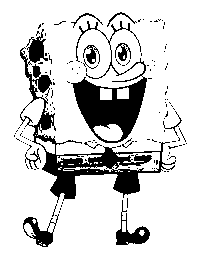

In [3]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes.png")

if img is None:
    print("Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    cv2_imshow(thresh)

2.Find Contours

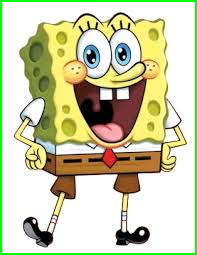

Number of Contours: 1


In [4]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

cv2.drawContours(img, contours, -1, (0,255,0), 2)

cv2_imshow(img)

print("Number of Contours:",len(contours))

3.Countour Area

In [5]:
import cv2

img = cv2.imread("shapes.png")

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

_,thresh=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

contours,_=cv2.findContours(thresh,
                            cv2.RETR_EXTERNAL,
                            cv2.CHAIN_APPROX_SIMPLE)

for i,cnt in enumerate(contours):

    area=cv2.contourArea(cnt)

    print("Contour",i+1,"Area =",area)

Contour 1 Area = 49784.0


4. Countour Perimeter

In [6]:
import cv2

img=cv2.imread("shapes.png")

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

_,thresh=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

contours,_=cv2.findContours(thresh,
                            cv2.RETR_EXTERNAL,
                            cv2.CHAIN_APPROX_SIMPLE)

for i,cnt in enumerate(contours):

    perimeter=cv2.arcLength(cnt,True)

    print("Contour",i+1,"Perimeter =",perimeter)

Contour 1 Perimeter = 900.0


5. Shape Detection

Number of Objects: 1
------------------------
Object : 1
Shape : Circle
Area : 81966.0
Perimeter : 1070.5727189779282


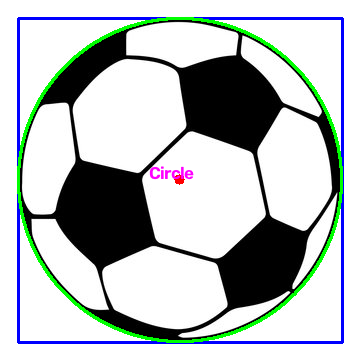

In [10]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes1.png")

if img is None:
    print("Error: Image not found!")
    exit()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of Objects:", len(contours))

count = 1

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < 100:
        continue

    perimeter = cv2.arcLength(cnt, True)

    approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)

    vertices = len(approx)


    if vertices == 3:
        shape = "Triangle"

    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)

        ratio = w / float(h)

        if 0.95 <= ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    elif vertices == 5:
        shape = "Pentagon"

    elif vertices == 6:
        shape = "Hexagon"

    else:
        shape = "Circle"


    x, y, w, h = cv2.boundingRect(cnt)

    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    cv2.drawContours(img, [cnt], -1, (0, 255, 0), 2)

    M = cv2.moments(cnt)

    if M["m00"] != 0:

        cx = int(M["m10"] / M["m00"])

        cy = int(M["m01"] / M["m00"])

        cv2.circle(img, (cx, cy), 5, (0, 0, 255), -1)

        cv2.putText(
            img,
            shape,
            (cx - 30, cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 255),
            2,
        )

    print("------------------------")
    print("Object :", count)
    print("Shape :", shape)
    print("Area :", area)
    print("Perimeter :", perimeter)

    count += 1

cv2_imshow(img)

6. Convex Hull

Convex Hull


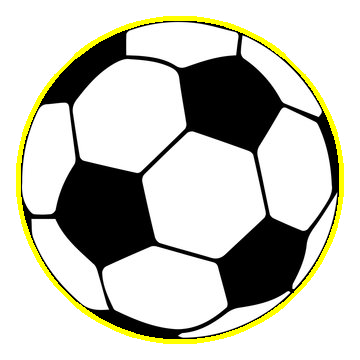

In [13]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes1.png")

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

_,thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY_INV)

contours,_ = cv2.findContours(thresh,
                              cv2.RETR_EXTERNAL,
                              cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:

    hull = cv2.convexHull(cnt)

    cv2.drawContours(img,[hull],-1,(0,255,255),3)
print("Convex Hull")
cv2_imshow(img)

7. Canny Edge Detection

Canny Edge Detection


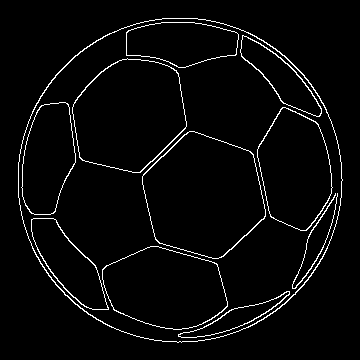

In [15]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes1.png")

if img is None:
    print("Error: Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    print("Canny Edge Detection")
    cv2_imshow(edges)

Scharr Edge Detection (X-direction)


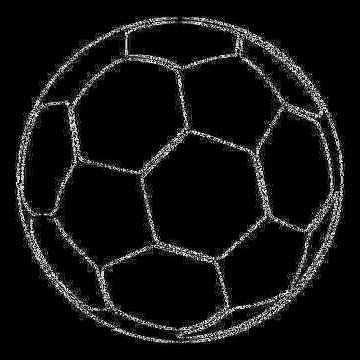

Scharr Edge Detection (Y-direction)


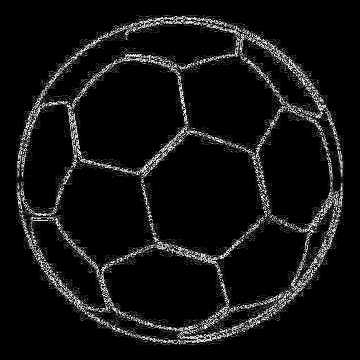

Scharr Edge Detection (Combined)


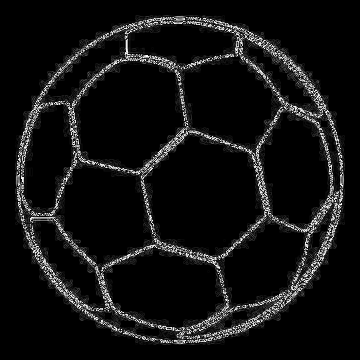

In [16]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes1.png")

if img is None:
    print("Error: Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Scharr operator in x direction
    scharrx = cv2.Scharr(gray, cv2.CV_64F, 1, 0)
    # Apply Scharr operator in y direction
    scharry = cv2.Scharr(gray, cv2.CV_64F, 0, 1)

    # Combine x and y gradient components
    scharr_combined = cv2.addWeighted(np.absolute(scharrx), 0.5, np.absolute(scharry), 0.5, 0)

    print("Scharr Edge Detection (X-direction)")
    cv2_imshow(np.absolute(scharrx).astype(np.uint8))

    print("Scharr Edge Detection (Y-direction)")
    cv2_imshow(np.absolute(scharry).astype(np.uint8))

    print("Scharr Edge Detection (Combined)")
    cv2_imshow(scharr_combined.astype(np.uint8))

8. Detecting Boundaries

Object Representation: Bounding Rectangles


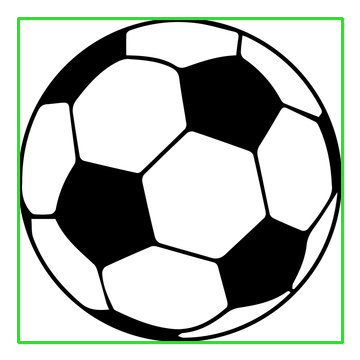

Object Representation: Minimum Enclosing Circles


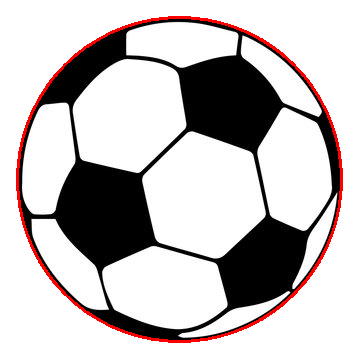

Object Representation: Fitted Ellipses


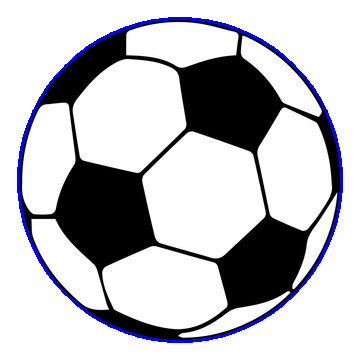

In [18]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes1.png")

if img is None:
    print("Error: Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_bbox = img.copy()
    img_min_circle = img.copy()
    img_ellipse = img.copy()

    for cnt in contours:
        if cv2.contourArea(cnt) < 100:  # Filter out small noise
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)

        (x_c, y_c), radius = cv2.minEnclosingCircle(cnt)
        center = (int(x_c), int(y_c))
        radius = int(radius)
        cv2.circle(img_min_circle, center, radius, (0, 0, 255), 2)

        if len(cnt) >= 5:
            ellipse = cv2.fitEllipse(cnt)
            cv2.ellipse(img_ellipse, ellipse, (255, 0, 0), 2)

    print("Object Representation: Bounding Rectangles")
    cv2_imshow(img_bbox)

    print("Object Representation: Minimum Enclosing Circles")
    cv2_imshow(img_min_circle)

    print("Object Representation: Fitted Ellipses")
    cv2_imshow(img_ellipse)

9. Laplacian Of Gaussian

Laplacian of Gaussian (LoG) Edge Detection


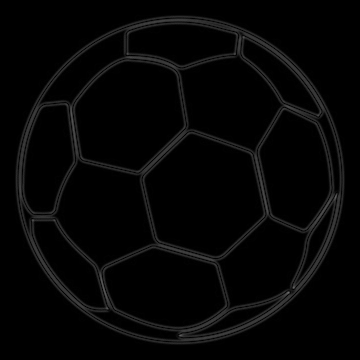

In [19]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("shapes1.png")

if img is None:
    print("Error: Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

    laplacian_8u = np.uint8(np.absolute(laplacian))

    print("Laplacian of Gaussian (LoG) Edge Detection")
    cv2_imshow(laplacian_8u)

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


Input data shape: (1, 128, 128, 1)
Output (ground truth) data shape: (1, 128, 128, 1)


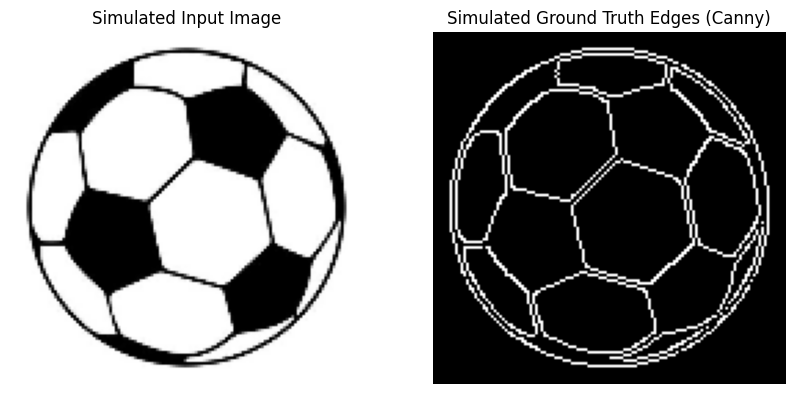

In [21]:

img_path = "shapes1.png"
image = cv2.imread(img_path)

if image is None:
    print("Error: Image not found!")
else:

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    input_shape = (128, 128)
    resized_image = cv2.resize(gray_image, input_shape)

    normalized_image = resized_image / 255.0


    ground_truth_edges = cv2.Canny(resized_image, 50, 150) / 255.0


    input_data = np.expand_dims(normalized_image, axis=(0, -1))
    output_data = np.expand_dims(ground_truth_edges, axis=(0, -1))

    print(f"Input data shape: {input_data.shape}")
    print(f"Output (ground truth) data shape: {output_data.shape}")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Simulated Input Image")
    plt.imshow(resized_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Simulated Ground Truth Edges (Canny)")
    plt.imshow(ground_truth_edges, cmap='gray')
    plt.axis('off')
    plt.show()

In [22]:
def build_simple_edge_detector(input_shape):
    inputs = keras.Input(shape=input_shape)

    conv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)


    conv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)

    up4 = layers.UpSampling2D((2, 2))(conv3)
    conv4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up4)

    up5 = layers.UpSampling2D((2, 2))(conv4)
    conv5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(up5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(conv5)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

model_input_shape = (*input_shape, 1)

edge_model = build_simple_edge_detector(model_input_shape)
edge_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,961 (722.50 KB)

 Trainable params: 184,961 (722.50 KB)

 Non-trainable params: 0 (0.00 B)

11.CNN

In [23]:

edge_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model compiled. Ready for training or prediction.")

Model compiled. Ready for training or prediction.


### Make a Prediction

After training, you would use the model to predict edges on new, unseen images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


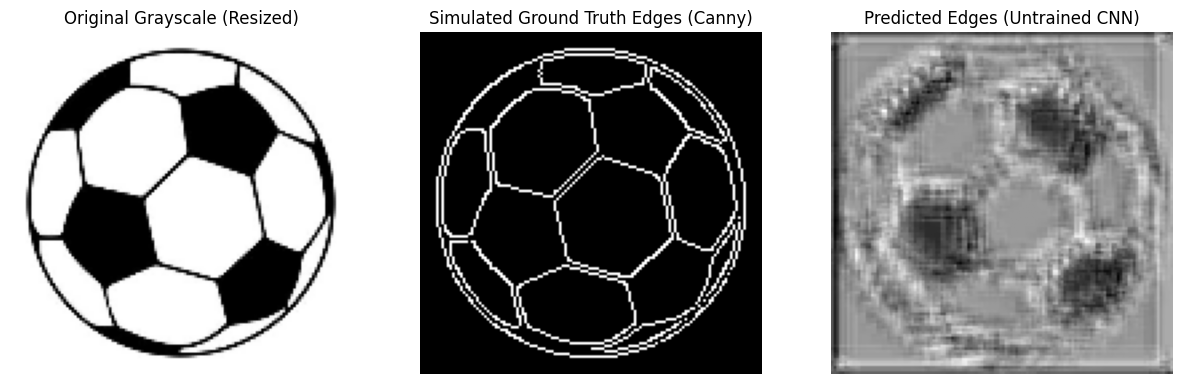

Note: The predicted edges from an untrained model will appear random.
A real application would involve extensive training on a proper dataset.


In [24]:
if image is not None:

    predicted_edges = edge_model.predict(input_data)[0, ..., 0]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original Grayscale (Resized)")
    plt.imshow(resized_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Simulated Ground Truth Edges (Canny)")
    plt.imshow(ground_truth_edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Edges (Untrained CNN)")
    plt.imshow(predicted_edges, cmap='gray')
    plt.axis('off')
    plt.show()

    print("Note: The predicted edges from an untrained model will appear random.")
    print("A real application would involve extensive training on a proper dataset.")